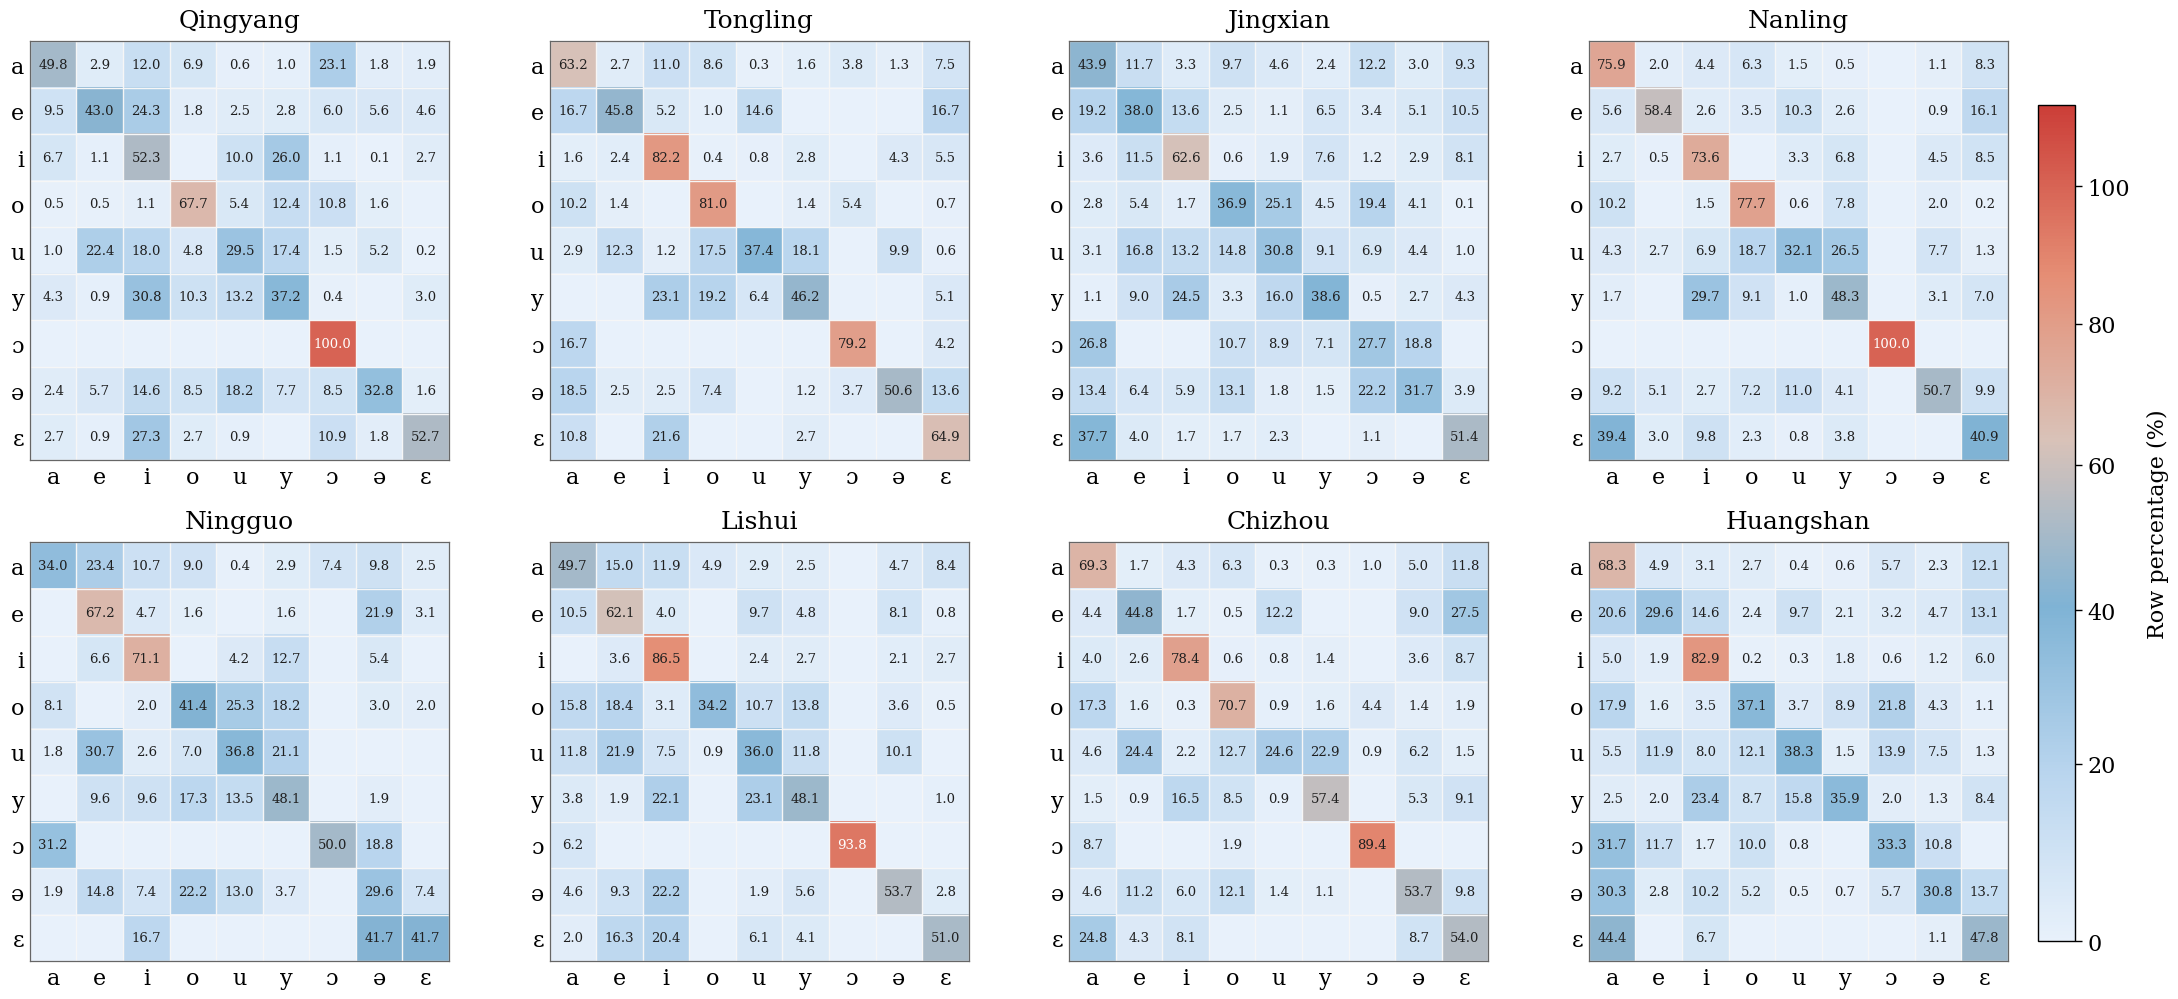

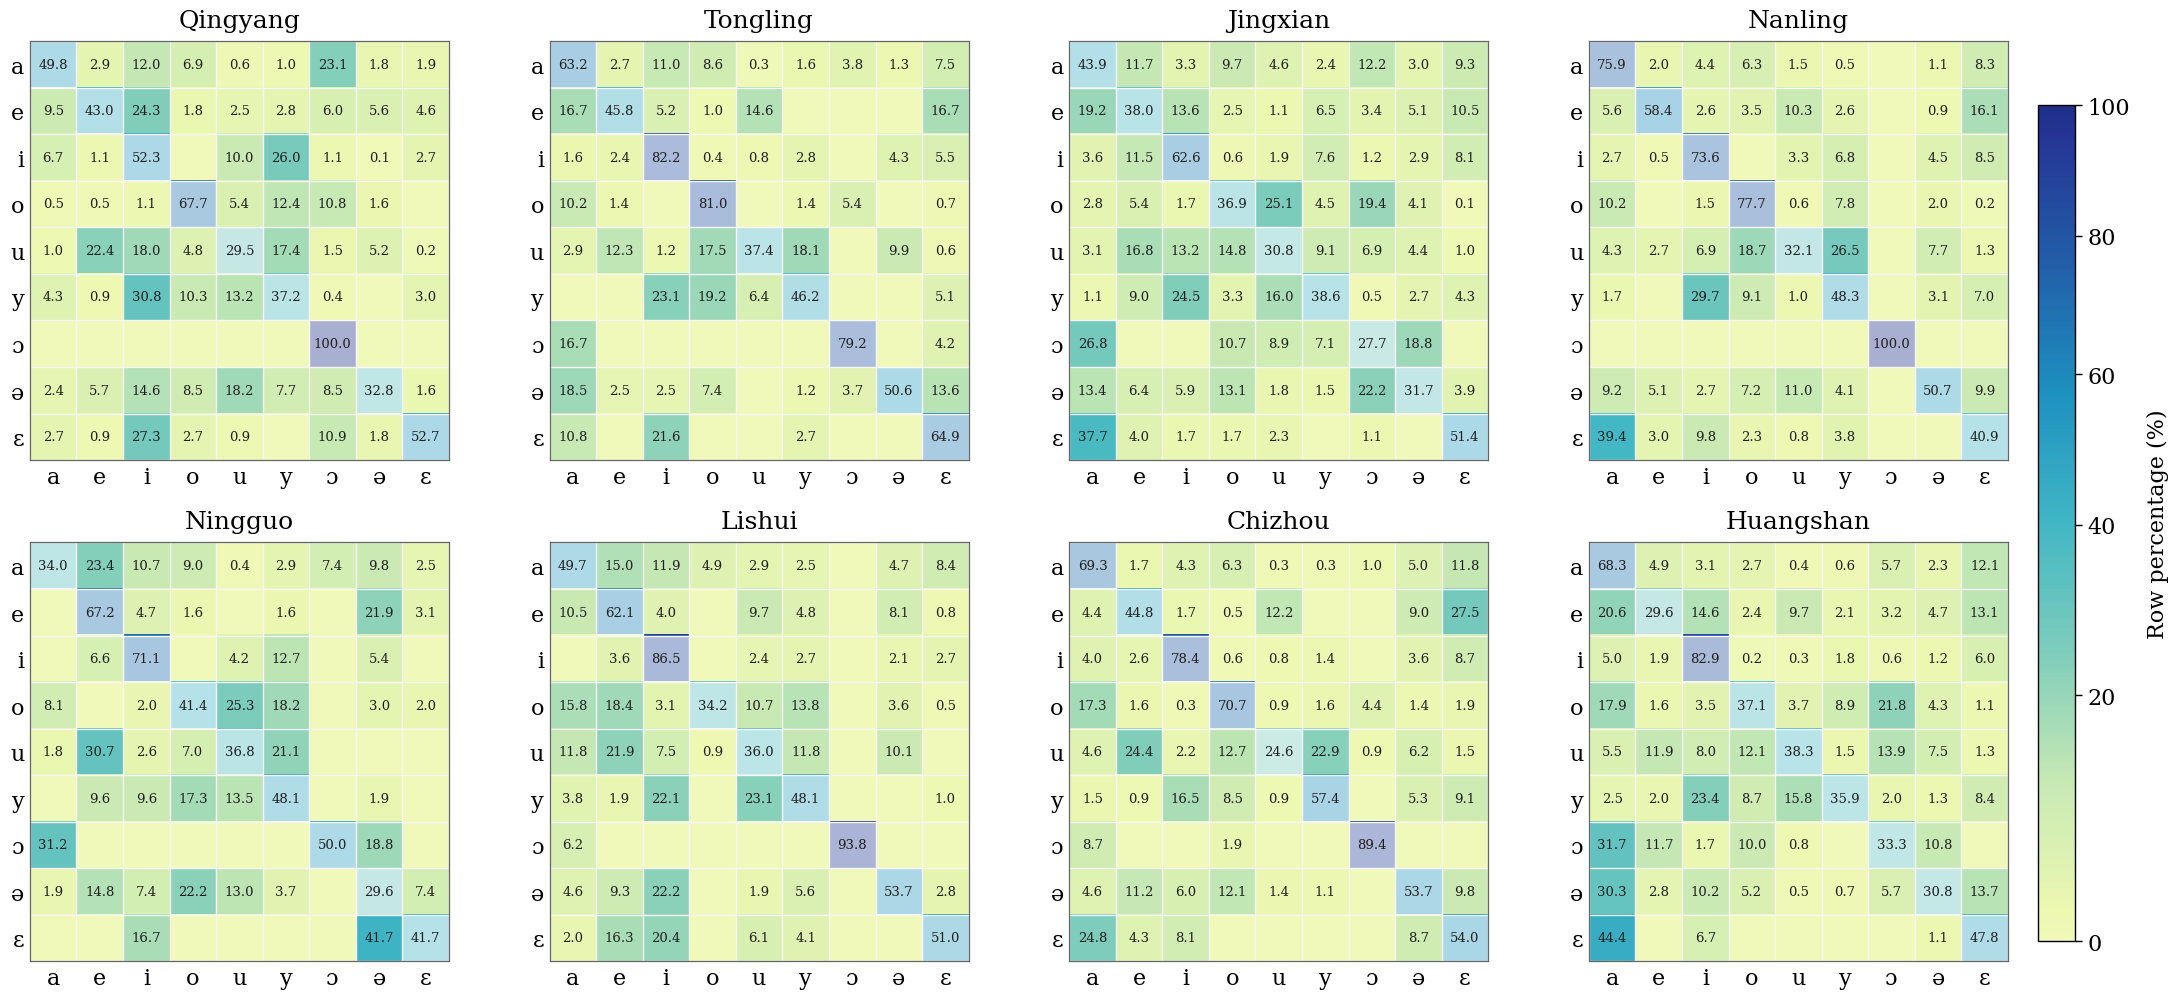


All figures saved to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid


In [11]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors, font_manager
from matplotlib.colors import Normalize, PowerNorm


# ============================================================
# 1. Configuration
# ============================================================
# Jupyter usage:
#   %matplotlib inline
#   %run plot_two_confusion_matrix_styles_jupyter.py
# Or paste this entire file into one notebook cell and run it.
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # When the full code is pasted directly into a Jupyter cell.
    BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "pc_dlcmnet_figures_hybrid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AREAS = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan",
]
LABELS = ["a", "e", "i", "o", "u", "y", "ɔ", "ə", "ɛ"]

# Move each row maximum to its diagonal location by swapping cells.
# This is a visualization-only adjustment and does not represent the original
# empirical confusion matrix.
FORCE_ROW_MAX_ON_DIAGONAL = True

NORMALIZE_ROWS = True
ANNOTATION_MODE = "percent"  # "percent", "count", "both", or "none"
HIDE_ZERO_TEXT = True

DPI = 300
SAVE_PNG = True
SAVE_PDF = True
SHOW_FIGURES = True

# =========================
# Figure and font settings
# =========================
FIGSIZE = (23.0, 11.0)
PREFERRED_FONTS = ["Times New Roman", "DejaVu Serif"]

# Region titles, e.g. Qingyang / Tongling.
TITLE_FONT_SIZE = 18
TITLE_FONT_WEIGHT = "normal"      # "normal" or "bold"
TITLE_PAD = 10

# Shared x/y axis labels: Predicted label / True label.
AXIS_LABEL_FONT_SIZE = 18
AXIS_LABEL_FONT_WEIGHT = "normal"

# Category tick labels: a, e, i, o, ...
TICK_FONT_SIZE = 16
TICK_PAD = 4

# Values printed inside each matrix cell.
CELL_FONT_SIZE = 9.5

# Right-side colorbar (legend) settings.
COLORBAR_TICK_FONT_SIZE = 16
COLORBAR_LABEL_FONT_SIZE = 16
COLORBAR_LABEL_PAD = 12
COLORBAR_TICK_LENGTH = 5
COLORBAR_TICK_WIDTH = 1.0
COLORBAR_OUTLINE_WIDTH = 1.0

# Colorbar position: [left, bottom, width, height].
COLORBAR_LEFT = 0.928
COLORBAR_BOTTOM = 0.12
COLORBAR_WIDTH = 0.016
COLORBAR_HEIGHT = 0.76

# Layout spacing.
SUBPLOT_LEFT = 0.055
SUBPLOT_RIGHT = 0.915
SUBPLOT_BOTTOM = 0.085
SUBPLOT_TOP = 0.955
SUBPLOT_WSPACE = 0.24
SUBPLOT_HSPACE = 0.1

GRID_COLOR = "#F6F6F6"
SPINE_COLOR = "#666666"


@dataclass(frozen=True)
class PlotStyle:
    name: str
    filename_suffix: str
    cmap: colors.Colormap
    vmin: float
    vmax: float
    use_power_norm: bool
    gamma: float
    diagonal_lighten_alpha: float
    diagonal_text_bold: bool = False


# ============================================================
# 2. Embedded confusion-count matrices
# ============================================================
CONFUSION_COUNTS = {'Qingyang': [[255, 32, 132, 76, 7, 11, 549, 20, 21],
              [27, 122, 69, 5, 7, 8, 17, 16, 13],
              [50, 8, 392, 0, 75, 195, 8, 1, 20],
              [2, 2, 5, 300, 24, 55, 48, 7, 0],
              [5, 117, 94, 154, 25, 91, 8, 27, 1],
              [10, 2, 72, 24, 31, 87, 1, 0, 7],
              [0, 0, 0, 0, 0, 0, 72, 0, 0],
              [6, 14, 36, 81, 45, 19, 21, 21, 4],
              [58, 1, 30, 3, 1, 0, 12, 2, 3]],
 'Tongling': [[235, 10, 41, 32, 1, 6, 14, 5, 28],
              [16, 44, 5, 1, 14, 0, 0, 0, 16],
              [4, 6, 208, 1, 2, 7, 0, 11, 14],
              [15, 2, 0, 119, 0, 2, 8, 0, 1],
              [5, 21, 2, 64, 30, 31, 0, 17, 1],
              [0, 0, 18, 15, 5, 36, 0, 0, 4],
              [19, 0, 0, 0, 0, 0, 4, 0, 1],
              [15, 2, 2, 6, 0, 1, 3, 41, 11],
              [4, 0, 8, 0, 0, 1, 0, 0, 24]],
 'Jingxian': [[764, 204, 57, 169, 80, 41, 212, 52, 162],
              [86, 170, 61, 11, 5, 29, 15, 23, 47],
              [42, 134, 732, 7, 22, 89, 14, 34, 95],
              [19, 37, 12, 173, 254, 31, 134, 28, 1],
              [25, 134, 106, 118, 246, 73, 55, 35, 8],
              [4, 33, 90, 12, 142, 59, 2, 10, 16],
              [30, 0, 0, 31, 10, 8, 12, 21, 0],
              [52, 25, 23, 51, 7, 6, 86, 123, 15],
              [90, 7, 3, 3, 4, 0, 2, 0, 66]],
 'Nanling': [[1006, 26, 58, 83, 20, 7, 0, 15, 110],
             [19, 35, 9, 12, 199, 9, 0, 3, 55],
             [25, 5, 673, 0, 30, 62, 0, 41, 78],
             [55, 0, 8, 419, 3, 42, 0, 11, 1],
             [27, 17, 43, 117, 201, 166, 0, 48, 8],
             [5, 0, 85, 26, 3, 138, 0, 9, 20],
             [87, 0, 0, 0, 0, 0, 0, 0, 0],
             [27, 15, 8, 21, 32, 12, 0, 148, 29],
             [54, 4, 13, 3, 1, 5, 0, 0, 52]],
 'Ningguo': [[24, 57, 26, 22, 1, 7, 18, 83, 6],
             [0, 43, 3, 1, 0, 1, 0, 14, 2],
             [0, 11, 118, 0, 7, 21, 0, 9, 0],
             [8, 0, 2, 41, 25, 18, 0, 3, 2],
             [2, 35, 3, 42, 8, 24, 0, 0, 0],
             [0, 5, 5, 9, 7, 25, 0, 1, 0],
             [5, 0, 0, 0, 0, 0, 3, 8, 0],
             [1, 8, 4, 16, 7, 2, 0, 12, 4],
             [0, 0, 4, 0, 0, 0, 0, 10, 10]],
 'Lishui': [[242, 73, 58, 24, 14, 12, 0, 23, 41],
            [13, 77, 5, 0, 12, 6, 0, 10, 1],
            [0, 12, 289, 0, 8, 9, 0, 7, 9],
            [31, 36, 6, 67, 21, 27, 0, 7, 1],
            [27, 50, 17, 2, 82, 27, 0, 23, 0],
            [4, 2, 23, 0, 24, 50, 0, 0, 1],
            [30, 0, 0, 0, 0, 0, 2, 0, 0],
            [5, 10, 24, 0, 2, 6, 0, 58, 3],
            [1, 8, 25, 0, 3, 2, 0, 0, 10]],
 'Chizhou': [[1115, 27, 69, 102, 5, 5, 16, 80, 189],
             [18, 184, 7, 2, 50, 0, 0, 37, 113],
             [43, 28, 849, 6, 9, 15, 0, 39, 94],
             [111, 10, 2, 454, 6, 10, 28, 9, 12],
             [35, 185, 17, 186, 96, 173, 7, 47, 11],
             [5, 3, 56, 29, 3, 195, 0, 18, 31],
             [93, 0, 0, 2, 0, 0, 9, 0, 0],
             [16, 39, 21, 42, 5, 4, 0, 187, 34],
             [40, 7, 13, 0, 0, 0, 0, 14, 87]],
 'Huangshan': [[1252, 90, 56, 49, 7, 11, 104, 43, 221],
               [96, 138, 68, 11, 45, 10, 15, 22, 61],
               [63, 24, 1040, 3, 4, 22, 8, 15, 75],
               [132, 12, 26, 274, 27, 66, 161, 32, 8],
               [47, 102, 68, 103, 327, 13, 119, 64, 11],
               [10, 8, 141, 34, 62, 92, 8, 5, 33],
               [40, 14, 2, 12, 1, 0, 38, 13, 0],
               [130, 12, 43, 22, 2, 3, 24, 128, 58],
               [85, 0, 12, 0, 0, 0, 0, 2, 79]]}


# ============================================================
# 3. Data utilities
# ============================================================
def validate_matrices() -> None:
    expected_shape = (len(LABELS), len(LABELS))
    for area in AREAS:
        if area not in CONFUSION_COUNTS:
            raise KeyError(f"Missing matrix for {area}")
        matrix = np.asarray(CONFUSION_COUNTS[area], dtype=np.int64)
        if matrix.shape != expected_shape:
            raise ValueError(
                f"{area} has shape {matrix.shape}, expected {expected_shape}."
            )
        if np.any(matrix < 0):
            raise ValueError(f"{area} contains negative counts.")


def force_row_max_on_diagonal(counts: np.ndarray) -> np.ndarray:
    adjusted = np.asarray(counts, dtype=np.int64).copy()
    if adjusted.ndim != 2 or adjusted.shape[0] != adjusted.shape[1]:
        raise ValueError("A square matrix is required.")

    for row_index in range(adjusted.shape[0]):
        max_col = int(np.argmax(adjusted[row_index]))
        if max_col != row_index:
            adjusted[row_index, row_index], adjusted[row_index, max_col] = (
                adjusted[row_index, max_col],
                adjusted[row_index, row_index],
            )
    return adjusted


def get_plot_counts(area: str) -> np.ndarray:
    counts = np.asarray(CONFUSION_COUNTS[area], dtype=np.int64)
    if FORCE_ROW_MAX_ON_DIAGONAL:
        counts = force_row_max_on_diagonal(counts)
    return counts


def verify_adjustment() -> None:
    if not FORCE_ROW_MAX_ON_DIAGONAL:
        return
    for area in AREAS:
        counts = get_plot_counts(area)
        if not np.all(np.diag(counts) == counts.max(axis=1)):
            raise AssertionError(f"Diagonal adjustment failed for {area}")


def row_normalize(counts: np.ndarray) -> np.ndarray:
    counts = np.asarray(counts, dtype=np.float64)
    row_totals = counts.sum(axis=1, keepdims=True)
    return np.divide(
        counts,
        row_totals,
        out=np.zeros_like(counts),
        where=row_totals != 0,
    ) * 100.0


def calculate_accuracy(counts: np.ndarray) -> float:
    total = float(np.sum(counts))
    return float(np.trace(counts) / total) if total else 0.0


def make_cell_text(count: int, percent: float) -> str:
    mode = ANNOTATION_MODE.lower()
    if mode == "none":
        return ""
    if mode == "count":
        return str(count)
    if mode == "percent":
        return f"{percent:.1f}"
    if mode == "both":
        return f"{percent:.1f}%\n({count})"
    raise ValueError('ANNOTATION_MODE must be "percent", "count", "both", or "none".')


# ============================================================
# 4. Colormaps and styles
# ============================================================
def make_blue_to_red_cmap() -> colors.Colormap:
    # Low values are light blue; high values are red.
    palette = [
        "#e8f1fb",
        "#b9d5ee",
        "#7fb3d5",
        "#d9c2b8",
        "#e58d74",
        "#cb3e38",
    ]
    return colors.LinearSegmentedColormap.from_list(
        "blue_to_red", palette, N=256
    )


def truncate_cmap(
    cmap_name: str,
    min_value: float,
    max_value: float,
    sample_count: int = 256,
) -> colors.Colormap:
    base = plt.colormaps.get_cmap(cmap_name)
    sampled = base(np.linspace(min_value, max_value, sample_count))
    return colors.LinearSegmentedColormap.from_list(
        f"truncated_{cmap_name}", sampled, N=sample_count
    )


def build_styles() -> list[PlotStyle]:
    return [
        PlotStyle(
            name="Blue–Red",
            filename_suffix="blue_red",
            cmap=make_blue_to_red_cmap(),
            vmin=0.0,
            vmax=112.0,
            use_power_norm=True,
            gamma=0.90,
            diagonal_lighten_alpha=0.0,
        ),
        PlotStyle(
            name="Yellow–Green–Blue",
            filename_suffix="yellow_green_blue",
            cmap=truncate_cmap("YlGnBu", 0.10, 0.90),
            vmin=0.0,
            vmax=100.0,
            use_power_norm=True,
            gamma=0.76,
            diagonal_lighten_alpha=0.62,
        ),
    ]


def get_norm(style: PlotStyle) -> Normalize:
    if style.use_power_norm:
        return PowerNorm(
            gamma=style.gamma,
            vmin=style.vmin,
            vmax=style.vmax,
        )
    return Normalize(vmin=style.vmin, vmax=style.vmax)


# ============================================================
# 5. Plotting
# ============================================================
def choose_font() -> str:
    available = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in PREFERRED_FONTS:
        if font_name in available:
            return font_name
    return "DejaVu Serif"


def configure_matplotlib() -> None:
    plt.rcParams.update(
        {
            "font.family": choose_font(),
            "font.size": TICK_FONT_SIZE,
            "axes.unicode_minus": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def choose_text_color(
    value: float,
    norm: Normalize,
    cmap: colors.Colormap,
    row: int,
    col: int,
    diagonal_lighten_alpha: float,
) -> str:
    mapped = np.asarray(cmap(norm(min(value, norm.vmax))))[:3]
    if row == col and diagonal_lighten_alpha > 0:
        mapped = mapped * (1.0 - diagonal_lighten_alpha) + diagonal_lighten_alpha
    luminance = 0.2126 * mapped[0] + 0.7152 * mapped[1] + 0.0722 * mapped[2]
    return "#1F1F1F" if luminance > 0.58 else "white"


def draw_panel(
    ax: plt.Axes,
    area: str,
    style: PlotStyle,
    norm: Normalize,
) -> plt.AxesImage:
    counts = get_plot_counts(area)
    percentages = row_normalize(counts)
    displayed = percentages if NORMALIZE_ROWS else counts.astype(float)

    image = ax.imshow(
        displayed,
        cmap=style.cmap,
        norm=norm,
        interpolation="nearest",
        aspect="equal",
    )

    accuracy = calculate_accuracy(counts)
    ax.set_title(
        f"{area}",
        fontsize=TITLE_FONT_SIZE,
        fontweight=TITLE_FONT_WEIGHT,
        pad=TITLE_PAD,
    )

    indices = np.arange(len(LABELS))
    ax.set_xticks(indices)
    ax.set_yticks(indices)
    ax.set_xticklabels(LABELS, fontsize=TICK_FONT_SIZE)
    ax.set_yticklabels(LABELS, fontsize=TICK_FONT_SIZE)
    ax.tick_params(
        axis="both",
        which="major",
        length=0,
        pad=TICK_PAD,
        labelsize=TICK_FONT_SIZE,
    )

    ax.set_xticks(np.arange(-0.5, len(LABELS), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(LABELS), 1), minor=True)
    ax.grid(
        which="minor",
        color=GRID_COLOR,
        linestyle="-",
        linewidth=1.0,
        zorder=3,
    )
    ax.tick_params(which="minor", bottom=False, left=False)

    if style.diagonal_lighten_alpha > 0:
        for index in range(len(LABELS)):
            ax.add_patch(
                plt.Rectangle(
                    (index - 0.5, index - 0.5),
                    1,
                    1,
                    facecolor="white",
                    edgecolor="none",
                    alpha=style.diagonal_lighten_alpha,
                    zorder=2,
                )
            )

    for row in range(counts.shape[0]):
        for col in range(counts.shape[1]):
            count = int(counts[row, col])
            percent = float(percentages[row, col])
            if HIDE_ZERO_TEXT and count == 0:
                continue
            text = make_cell_text(count, percent)
            if not text:
                continue

            text_color = choose_text_color(
                value=float(displayed[row, col]),
                norm=norm,
                cmap=style.cmap,
                row=row,
                col=col,
                diagonal_lighten_alpha=style.diagonal_lighten_alpha,
            )
            fontweight = (
                "bold" if row == col and style.diagonal_text_bold else "normal"
            )
            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=CELL_FONT_SIZE,
                color=text_color,
                fontweight=fontweight,
                zorder=4,
            )

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)
        spine.set_edgecolor(SPINE_COLOR)

    return image


def save_figure(fig: plt.Figure, output_stem: Path) -> None:
    if SAVE_PNG:
        fig.savefig(
            output_stem.with_suffix(".png"),
            dpi=DPI,
            bbox_inches="tight",
        )
    if SAVE_PDF:
        fig.savefig(
            output_stem.with_suffix(".pdf"),
            dpi=DPI,
            bbox_inches="tight",
        )


def plot_style(style: PlotStyle) -> None:
    norm = get_norm(style)
    fig, axes = plt.subplots(2, 4, figsize=FIGSIZE)
    axes = axes.ravel()

    image = None
    for ax, area in zip(axes, AREAS):
        image = draw_panel(ax, area, style, norm)

    # fig.supxlabel(
    #     "Predicted label",
    #     fontsize=AXIS_LABEL_FONT_SIZE,
    #     fontweight=AXIS_LABEL_FONT_WEIGHT,
    #     y=0.035,
    # )
    # fig.supylabel(
    #     "True label",
    #     fontsize=AXIS_LABEL_FONT_SIZE,
    #     fontweight=AXIS_LABEL_FONT_WEIGHT,
    #     x=0.018,
    # )
    fig.subplots_adjust(
        left=SUBPLOT_LEFT,
        right=SUBPLOT_RIGHT,
        bottom=SUBPLOT_BOTTOM,
        top=SUBPLOT_TOP,
        wspace=SUBPLOT_WSPACE,
        hspace=SUBPLOT_HSPACE,
    )

    if image is not None:
        colorbar_axis = fig.add_axes(
            [
                COLORBAR_LEFT,
                COLORBAR_BOTTOM,
                COLORBAR_WIDTH,
                COLORBAR_HEIGHT,
            ]
        )
        colorbar = fig.colorbar(image, cax=colorbar_axis)
        colorbar.ax.tick_params(
            labelsize=COLORBAR_TICK_FONT_SIZE,
            length=COLORBAR_TICK_LENGTH,
            width=COLORBAR_TICK_WIDTH,
            pad=4,
        )
        colorbar.outline.set_linewidth(COLORBAR_OUTLINE_WIDTH)
        colorbar.set_label(
            "Row percentage (%)" if NORMALIZE_ROWS else "Count",
            fontsize=COLORBAR_LABEL_FONT_SIZE,
            labelpad=COLORBAR_LABEL_PAD,
        )

    adjustment_suffix = (
        "_rowmax_diagonal_adjusted" if FORCE_ROW_MAX_ON_DIAGONAL else ""
    )
    output_stem = OUTPUT_DIR / (
        f"confusion_matrices_2x4_{style.filename_suffix}"
        f"{adjustment_suffix}"
    )
    save_figure(fig, output_stem)

    if SHOW_FIGURES:
        plt.show()

    # Safe after plt.show(); releases memory and avoids duplicate notebook output.
    plt.close(fig)

    # print(f"Saved {style.name} figure: {output_stem}")


def main() -> None:
    validate_matrices()
    verify_adjustment()
    configure_matplotlib()

    if FORCE_ROW_MAX_ON_DIAGONAL:
        print(
            "WARNING: row maxima are swapped onto the diagonal for visualization. "
            "These are not the original empirical confusion matrices."
        )

    for style in build_styles():
        plot_style(style)

    print(f"\nAll figures saved to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()